<a href="https://colab.research.google.com/github/AnuradhaVimukthi/Statistical-Learning-e23148/blob/main/Kalman_filter_assignment_Answers.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Q. Analytical Derivation

### 1. Derivation of the Predicted State Distribution
Because the filter equation is a linear combination of Gaussian random variables, the predicted state $x_k^-$ is also Gaussian.
Taking the expectation of the state equation yields the predicted mean:
$$m_k^- \triangleq \mathbb{E}[x_k^-] = A_{k-1}\mathbb{E}[x_{k-1}^+] + G_{k-1}\mathbb{E}[w_{k-1}]$$

Since the process noise is zero-mean ($\mathbb{E}[w_{k-1}] = 0$), this simplifies to:
$$m_k^- = A_{k-1}m_{k-1}$$

The predicted covariance $P_k^-$ is computed by applying the variance operator:
$$P_k^- \triangleq \text{Var}(x_k^-) = A_{k-1}\text{Var}(x_{k-1}^+)A_{k-1}^T + G_{k-1}\text{Var}(w_{k-1})G_{k-1}^T$$

Substituting the known variances yields:
$$P_k^- = A_{k-1}P_{k-1}A_{k-1}^T + G_{k-1}\Sigma_p G_{k-1}^T$$
Thus, $x_k^- \sim \mathscr{N}(m_k^-, P_k^-)$.

---

### 2. Derivation of the Predicted Measurement Distribution
Prior to its physical realization, the upcoming measurement $y_k^-$ is treated as a random variable. Its expected value is:
$$\mathbb{E}[y_k^-] = H_k\mathbb{E}[x_k^-] + \mathbb{E}[z_k] = H_k m_k^-$$

Its variance is computed similarly to the state variance:
$$\text{Var}(y_k^-) = H_k \text{Var}(x_k^-) H_k^T + \text{Var}(z_k) = H_k P_k^- H_k^T + \Sigma_m$$
Thus, $y_k^- \sim \mathscr{N}(H_k m_k^-, H_k P_k^- H_k^T + \Sigma_m)$.

---

### 3. The Joint Prior Distribution
To form the joint distribution, we need the cross-covariance between the predicted state $x_k^-$ and the anticipated measurement $y_k^-$:
$$\text{Cov}(x_k^-, y_k^-) = \text{Cov}(x_k^-, H_k x_k^- + z_k) = P_k^- H_k^T$$

Combining the individual means, variances, and the cross-covariance, the joint distribution is a block-structured multivariate Gaussian:
$$\begin{bmatrix} x_k^- \\ y_k^- \end{bmatrix} \sim \mathscr{N}\left(\begin{bmatrix} m_k^- \\ H_k m_k^- \end{bmatrix}, \begin{bmatrix} P_k^- & P_k^- H_k^T \\ H_k P_k^- & H_k P_k^- H_k^T + \Sigma_m \end{bmatrix}\right)$$

---

### 4. The Measurement Update (Posterior Distribution)
Applying the standard conditioning properties of multivariate normal distributions (using the Schur complement), we update our prior belief by slicing the joint distribution at the realization $y_k = y_k^{\mathrm{obs}}$.
The conditional mean and covariance are given by standard Gaussian conditioning identities:
$$K_k \triangleq P_k^- H_k^T (H_k P_k^- H_k^T + \Sigma_m)^{-1}$$
$$m_k = m_k^- + K_k (y_k^{\mathrm{obs}} - H_k m_k^-)$$
$$P_k = P_k^- - K_k H_k P_k^- = (I - K_k H_k) P_k^-$$
Thus, $x_k^+ \sim \mathscr{N}(m_k, P_k)$.

---

### 5. Conditional Expectation and Variance
By the definition of the posterior distribution derived in step 4:
$$\mathbb{E}[x_k^- \mid y_k^- = y_k^{\mathrm{obs}}] = m_k$$
$$\text{Var}(x_k^- \mid y_k^- = y_k^{\mathrm{obs}}) = P_k$$

# Q. 1-D Example

### 1. 1-D Prediction Step
For a scalar system, matrix multiplication reduces to standard scalar multiplication. Substituting $A = a$ and $G = 1$ into the prediction equations:
$$m_k^- = a m_{k-1}$$
$$P_k^- = a P_{k-1} a + (1) q (1) = a^2 P_{k-1} + q$$

---

### 2. 1-D Update Step
The Kalman gain for a scalar system simplifies where matrix inversion becomes scalar division. Let the innovation variance be $S_k = h^2 P_k^- + r$.
$$K_k = \frac{P_k^- h}{S_k}$$
Substituting this into the update equations:
$$m_k = m_k^- + K_k v_k = m_k^- + \frac{P_k^- h}{S_k} (y_k^{\mathrm{obs}} - h m_k^-)$$
$$P_k = (1 - K_k h) P_k^- = \left(1 - \frac{P_k^- h^2}{S_k}\right) P_k^-$$

---

### 3. Predictive Measurement Distribution
Before the observation, the predicted measurement is $y_k^- = h x_k^- + z_k$.
* **Mean:** $\mathbb{E}[h x_k^- + z_k] = h m_k^-$
* **Variance:** $\text{Var}(h x_k^- + z_k) = h^2 P_k^- + r$

Thus, $p(y_k^- \mid Y_{k-1}) = \mathscr{N}(h m_k^-, h^2 P_k^- + r)$.

---

### 4. Posterior-predictive Measurement Distribution
After updating the state belief to $x_k \sim \mathscr{N}(m_k, P_k)$, the expected measurement distribution shifts:
* **Mean:** $\mathbb{E}[h x_k^+ + z_k] = h m_k$
* **Variance:** $\text{Var}(h x_k^+ + z_k) = h^2 P_k + r$

Thus, $p(y_k^- \mid Y_k) = \mathscr{N}(h m_k, h^2 P_k + r)$.

In [3]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation
from scipy.stats import norm
from IPython.display import HTML

# 1. Define Parameters
a, q = 1.0, 0.5            # State transition and Process noise
h, r = 1.0, 1.0            # Measurement scale and Measurement noise
m_prev, P_prev = 0.0, 1.0  # Initial state belief
y_obs = 3.0                # Simulated observed measurement

# 2. Compute Filter Steps
# Prediction
m_prior = a * m_prev
P_prior = a**2 * P_prev + q

# Update
S = h**2 * P_prior + r
K = (P_prior * h) / S
m_post = m_prior + K * (y_obs - h * m_prior)
P_post = (1 - K * h) * P_prior

# Predictive measurement vs Posterior-predictive measurement distributions
y_prior_mean, y_prior_var = h * m_prior, h**2 * P_prior + r
y_post_mean, y_post_var = h * m_post, h**2 * P_post + r

# 3. Setup Animation
fig, ax = plt.subplots(figsize=(8, 5))
x_vals = np.linspace(-5, 8, 400)
line_prior, = ax.plot([], [], 'b-', lw=2, label=r"Predictive $p(y_k^- | Y_{k-1})$")
line_post, = ax.plot([], [], 'r-', lw=2, label=r"Posterior $p(y_k^- | Y_k)$")
obs_point, = ax.plot([], [], 'go', markersize=8, label="Observed $y_k$")

ax.set_xlim(-5, 8)
ax.set_ylim(0, 0.5)
ax.set_title("1-D Kalman Filter: Predictive vs Posterior Measurement")
ax.legend()
ax.grid(True, alpha=0.3)

def init():
    line_prior.set_data([], [])
    line_post.set_data([], [])
    obs_point.set_data([], [])
    return line_prior, line_post, obs_point

def update(frame):
    # Transition smoothly from Prior to Posterior for visual effect
    alpha = frame / 50.0

    current_mean = (1 - alpha) * y_prior_mean + alpha * y_post_mean
    current_var = (1 - alpha) * y_prior_var + alpha * y_post_var

    y_pdf = norm.pdf(x_vals, current_mean, np.sqrt(current_var))

    # Keep prior static as background reference, animate posterior morphing
    line_prior.set_data(x_vals, norm.pdf(x_vals, y_prior_mean, np.sqrt(y_prior_var)))
    line_post.set_data(x_vals, y_pdf)

    if alpha > 0.5:
        obs_point.set_data([y_obs], [norm.pdf(y_obs, current_mean, np.sqrt(current_var))])

    return line_prior, line_post, obs_point

ani = FuncAnimation(fig, update, frames=51, init_func=init, blit=True, interval=60)
plt.close() # Prevent static plot rendering

# Display in Colab
HTML(ani.to_jshtml())

# Q. 2D-Position Estimation

### Derivation of A, H, and G
Assuming a sampling interval $\Delta t$, the continuous-time constant-velocity kinematic equations are discretized as follows:
$$p_x(k) = p_x(k-1) + \Delta t v_x(k-1)$$
$$p_y(k) = p_y(k-1) + \Delta t v_y(k-1)$$
$$v_x(k) = v_x(k-1)$$
$$v_y(k) = v_y(k-1)$$

Expressing this system of linear equations in matrix form ($x_k = A x_{k-1}$) gives the state transition matrix $A$:
$$A = \begin{bmatrix} 1 & 0 & \Delta t & 0 \\ 0 & 1 & 0 & \Delta t \\ 0 & 0 & 1 & 0 \\ 0 & 0 & 0 & 1 \end{bmatrix}$$

Since the measurement only extracts the two position components $(p_x, p_y)$ from the 4-dimensional state vector, the measurement matrix $H$ maps the state to the observation space:
$$H = \begin{bmatrix} 1 & 0 & 0 & 0 \\ 0 & 1 & 0 & 0 \end{bmatrix}$$

To model uncertainty, we assume random unmodeled acceleration acts as the process noise $w_{k-1} = [a_x(k-1), a_y(k-1)]^T$. Over one interval $\Delta t$, constant acceleration affects position by $\frac{1}{2}\Delta t^2$ (from $d = v_0t + \frac{1}{2}at^2$) and velocity by $\Delta t$:
$$p_x(k) = p_x(k-1) + \Delta t v_x(k-1) + \frac{1}{2}\Delta t^2 a_x(k-1)$$
$$v_x(k) = v_x(k-1) + \Delta t a_x(k-1)$$

(The $y$ components behave identically). Factoring out $[a_x, a_y]^T$ yields the noise mapping matrix $G$:
$$G = \begin{bmatrix} \frac{1}{2}\Delta t^2 & 0 \\ 0 & \frac{1}{2}\Delta t^2 \\ \Delta t & 0 \\ 0 & \Delta t \end{bmatrix}$$

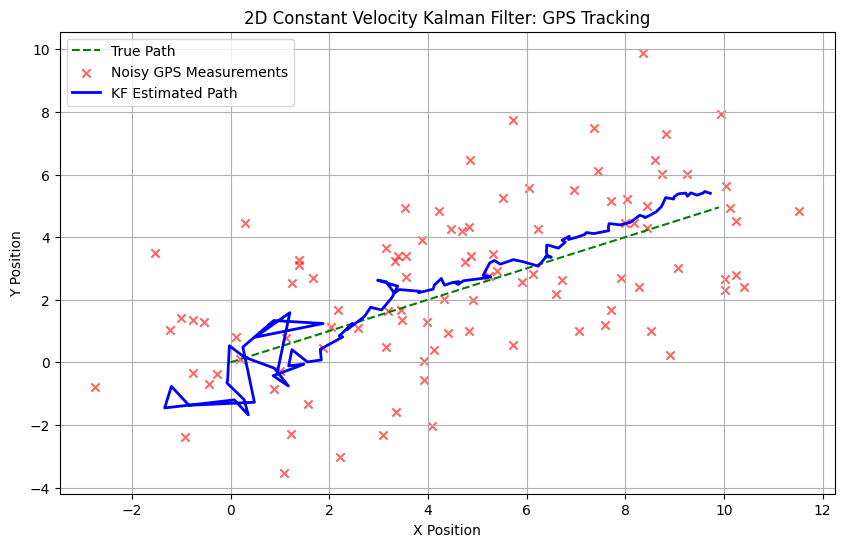

In [4]:
import numpy as np
import matplotlib.pyplot as plt

class KalmanFilter2D:
    def __init__(self, dt, q_variance, r_variance):
        self.dt = dt

        # State Transition Matrix (A)
        self.A = np.array([
            [1, 0, dt, 0],
            [0, 1, 0,  dt],
            [0, 0, 1,  0],
            [0, 0, 0,  1]
        ])

        # Measurement Matrix (H)
        self.H = np.array([
            [1, 0, 0, 0],
            [0, 1, 0, 0]
        ])

        # Process Noise Mapping Matrix (G)
        self.G = np.array([
            [0.5 * dt**2, 0],
            [0, 0.5 * dt**2],
            [dt, 0],
            [0, dt]
        ])

        # Covariance Matrices
        self.Sigma_p = np.eye(2) * q_variance
        self.Q = self.G @ self.Sigma_p @ self.G.T # Q = G * Sigma_p * G^T
        self.R = np.eye(2) * r_variance

        # Initial State (m_0) and Covariance (P_0)
        self.m = np.zeros((4, 1))
        self.P = np.eye(4) * 100

    def filter_step(self, y_obs):
        # 1. Prediction (Time Update)
        m_prior = self.A @ self.m
        P_prior = self.A @ self.P @ self.A.T + self.Q

        # 2. Correction (Measurement Update)
        S = self.H @ P_prior @ self.H.T + self.R
        K = P_prior @ self.H.T @ np.linalg.inv(S)

        # Reshape observation to (2, 1) column vector
        y = np.array(y_obs).reshape(2, 1)

        self.m = m_prior + K @ (y - self.H @ m_prior)
        self.P = (np.eye(4) - K @ self.H) @ P_prior

        return self.m.flatten()

# --- Simulation and Plotting ---
dt = 0.1
num_steps = 100
true_velocity = [1.0, 0.5] # Moving diagonally

# Generate noisy GPS data
np.random.seed(42)
true_positions = np.array([[k * dt * true_velocity[0], k * dt * true_velocity[1]] for k in range(num_steps)])
gps_measurements = true_positions + np.random.normal(0, 2.0, size=(num_steps, 2))

# Initialize Filter
kf = KalmanFilter2D(dt=dt, q_variance=0.01, r_variance=4.0)

# Run Filter over data
filtered_states = []
for y in gps_measurements:
    state = kf.filter_step(y)
    filtered_states.append(state)

filtered_states = np.array(filtered_states)

# Plot Results
plt.figure(figsize=(10, 6))
plt.plot(true_positions[:, 0], true_positions[:, 1], 'g--', label="True Path")
plt.scatter(gps_measurements[:, 0], gps_measurements[:, 1], c='r', marker='x', alpha=0.6, label="Noisy GPS Measurements")
plt.plot(filtered_states[:, 0], filtered_states[:, 1], 'b-', linewidth=2, label="KF Estimated Path")

plt.title("2D Constant Velocity Kalman Filter: GPS Tracking")
plt.xlabel("X Position")
plt.ylabel("Y Position")
plt.legend()
plt.grid(True)
plt.show()